In [1]:
import matplotlib.pyplot as plt
import random
import time
import math
import numpy as np

In [2]:
# function for the analysis of time complexity with plots
def Analyse_Plot(size,theory,actual):
    c = (actual[-1])/(theory[-1]) # matching the last values to get the constant to scale with
    theory_scaled = [c*t for t in theory] # scaled theoretical times

    plt.plot(size,theory_scaled,c='r',label='theoretical')
    plt.plot(size,actual,label='actual')
    plt.legend()
    plt.yscale("log")
    plt.xscale("log")
    plt.show()

#function for generating random list/array:
def generate(n):
    array = [random.randint(-1000,1000) for i in range(n)]
    return array

In [3]:
# max subarray recursion
def mid_cross_max_subarray(A, low, mid, high):
    left_sum = float("-inf")
    total = 0
    max_left = mid

    for i in range(mid, low - 1, -1):
        total += A[i]

        if total > left_sum:
            left_sum = total
            max_left = i

    right_sum = float("-inf")
    total = 0
    max_right = mid + 1

    for j in range(mid + 1, high + 1):
        total += A[j]

        if total > right_sum:
            right_sum = total
            max_right = j

    return (max_left, max_right, left_sum + right_sum)


def max_subarray(A, low, high):
    # Base case
    if low == high:
        return (low, high, A[low])

    mid = (low + high) // 2

    left = max_subarray(A, low, mid)
    right = max_subarray(A, mid + 1, high)
    cross = mid_cross_max_subarray(A, low, mid, high)

    if left[2] >= right[2] and left[2] >= cross[2]:
        return left

    elif right[2] >= left[2] and right[2] >= cross[2]:
        return right

    else:
        return cross

In [4]:
sizes = [10,50,100,500,1000,10000,50000,100000,500000,1000000]
actual = []
for size in sizes:
    array = generate(size)
    start = time.perf_counter()
    max_subarray(array,0,size-1)
    time_taken = time.perf_counter()-start
    actual.append(time_taken) # appending the time taken

# The recurrence relation for the max subarray alogorithm : T(n) = 2T(n/2) + n
# From recursion tree ,theoretically, T(n) = O(nlogn)
theory = [n*(math.log2(n)) for n in sizes]


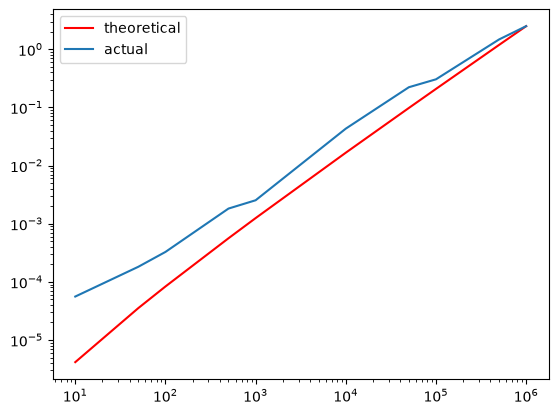

In [5]:
Analyse_Plot(sizes,theory,actual) # analyse plot

In [6]:
# general analyser function:
def Time_Analyse(algorithm, time_func, *args,max_size=5,min_size=1):

    sizes = np.unique(np.logspace(min_size, max_size, 100, dtype=int)).tolist()

    actual = []
    theory = []

    for size in sizes:

        array = generate(size)

        actual_args = [
            arg(array) if callable(arg) else arg
            for arg in args
        ]

        start = time.perf_counter()

        algorithm(array, *actual_args)

        time_taken = time.perf_counter() - start

        actual.append(time_taken)
        theory.append(time_func(size))

    c = actual[-1] / theory[-1]
    theory_scaled = [c * t for t in theory]

    plt.plot(sizes, theory_scaled, c='r', label='theoretical')
    plt.plot(sizes, actual, label='actual')

    plt.legend()
    plt.title("Time analysis")
    plt.xlabel("Size of the input")
    plt.ylabel("Time")

    plt.yscale("log")
    plt.xscale("log")
    plt.show()


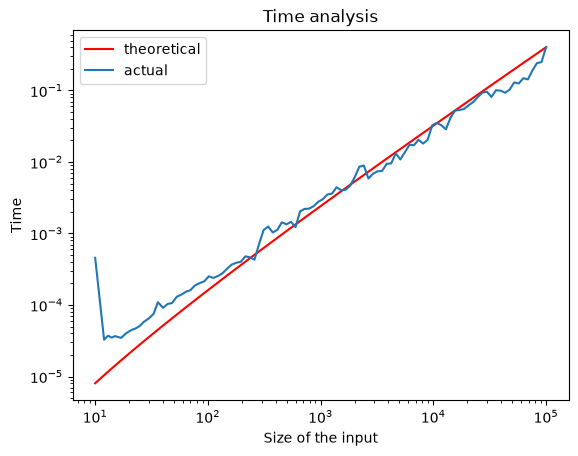

In [7]:
Time_Analyse(max_subarray,lambda n: n * math.log2(n),0,lambda arr: len(arr) - 1)# testing the function

In [8]:
# Toy algorithm
def toy_algorithm(arr):
    n = len(arr)

    # Base case
    if n <= 1:
        return arr[0] if n == 1 else None

    # Θ(n²) work
    total = 0
    for i in range(n):
        for j in range(n):
            total += arr[i] * arr[j]

    # Three recursive calls, each on n/4 elements
    q = n // 4

    a = toy_algorithm(arr[:q])
    b = toy_algorithm(arr[q:2*q])
    c = toy_algorithm(arr[2*q:3*q])

    return total + (a or 0) + (b or 0) + (c or 0)

'''
Recurrence relation:-
T(n) = 3T(n/4) + Θ(n^2)  => T(n) = Θ(n^2) mathematically.
'''   

'\nRecurrence relation:-\nT(n) = 3T(n/4) + Θ(n^2)  => T(n) = Θ(n^2) mathematically.\n'

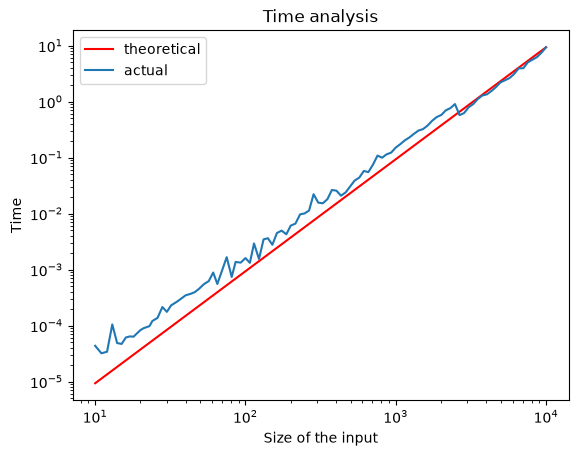

In [9]:
Time_Analyse(toy_algorithm,lambda n:n**2,max_size=4)

In [13]:

def recursive_algorithm(arr):
    n = len(arr)

    if n <= 1:
        return 1

    # Work proportional to n
    total = 0
    for i in range(n):
        total += i

    # Two recursive calls using smaller arrays
    return (
        total
        + recursive_algorithm(arr[:-1])
        + recursive_algorithm(arr[:n // 2])
    )

'''
Recurrence relation is :-
    T(n) = T(n - 1) + T(n / 2) + n
Mathematically, loose bound is O(2^n)[Upper bound] and Ω(nlogn)[Lower bound]      (Solved with sloppiness)

'''

'\nRecurrence relation is :-\n    T(n) = T(n - 1) + T(n / 2) + n\nMathematically, loose bound is O(2^n)[Upper bound] and Ω(nlogn)[Lower bound]      (Solved with sloppiness)\n\n'

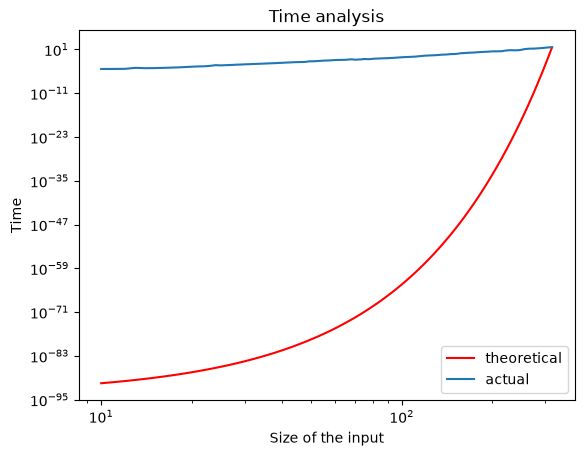

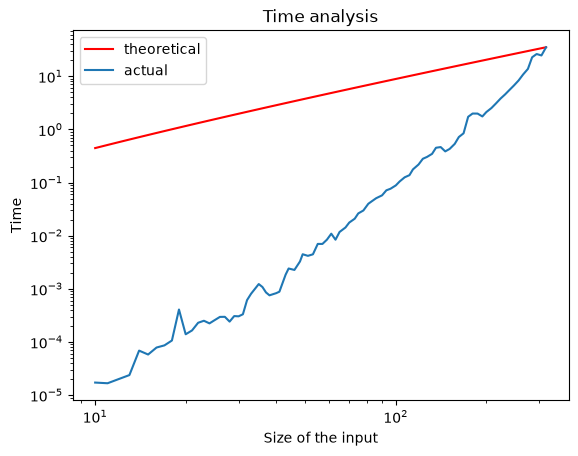

In [17]:
# Upper bound:
Time_Analyse(recursive_algorithm,lambda n:np.exp2(n),max_size=2.5)

#lower bound:
Time_Analyse(recursive_algorithm,lambda n: n * math.log2(n),max_size=2.5)

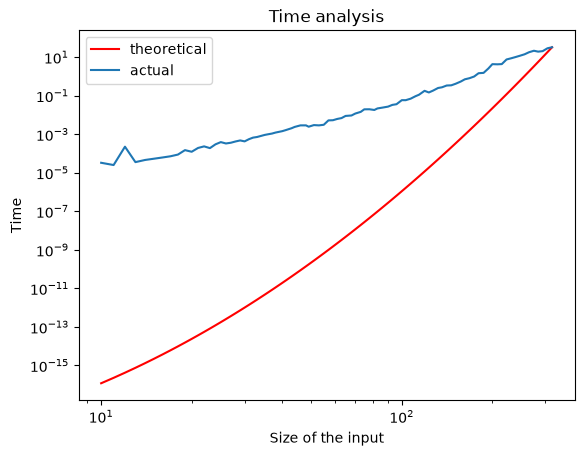

In [18]:
# Tight bound calculated is ~ Θ(n^logn)
Time_Analyse(recursive_algorithm,lambda n: n ** math.log2(n),max_size=2.5)